In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [2]:
train = pd.read_csv('../data/raw/train.csv')

train.info()
train

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [3]:
test = pd.read_csv('../data/raw/test.csv')

test.info()
test

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


In [4]:
train = train.drop(['Name','PassengerId'], axis=1)

passengerId = test['PassengerId']
test = test.drop(['Name','PassengerId'], axis=1)

In [5]:
print(train.describe())

               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.489021    666.717663   1611.489240    604.696458   1136.705535   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      19.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      38.000000     47.000000     76.000000     27.000000     59.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8505.000000  
mean     304.854791  
std     1145.717189  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       46.000000  
max    24133.000000  


In [6]:
for feature in train.columns:
    if type(train[feature][0]) in [str,bool,np.bool]:
        print(train[feature].value_counts(dropna=False))
        print('-'*30)

HomePlanet
Earth     4602
Europa    2131
Mars      1759
NaN        201
Name: count, dtype: int64
------------------------------
CryoSleep
False    5439
True     3037
NaN       217
Name: count, dtype: int64
------------------------------
Cabin
NaN         199
G/734/S       8
G/981/S       7
F/1411/P      7
C/137/S       7
           ... 
E/56/P        1
A/98/P        1
G/1499/S      1
G/1500/S      1
G/1494/S      1
Name: count, Length: 6561, dtype: int64
------------------------------
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
NaN               182
Name: count, dtype: int64
------------------------------
VIP
False    8291
NaN       203
True      199
Name: count, dtype: int64
------------------------------
Transported
True     4378
False    4315
Name: count, dtype: int64
------------------------------


In [7]:
# Simple Impute to deal with missing values
# Categorical data
cols = ["Destination", "Cabin", "HomePlanet"]
train[cols] = train[cols].fillna("NA")
test[cols] = test[cols].fillna("NA")

cat_cols = test.select_dtypes(include=["object","bool"]).columns

impute = sk.impute.SimpleImputer(strategy="most_frequent")

train[cat_cols] = impute.fit_transform(train[cat_cols])
test[cat_cols] = impute.transform(test[cat_cols])

# Numerical data
cat_cols = test.select_dtypes(include=[np.float64]).columns

impute = sk.impute.SimpleImputer(strategy="median")

train[cat_cols] = impute.fit_transform(train[cat_cols])
test[cat_cols] = impute.transform(test[cat_cols])

In [8]:
# Log Transform
# Compresses extreme values
# Keeps ranking
# Keeps signal

skewed_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

for df in [test,train]:    
    for col in skewed_cols:
        df[col] = np.log1p(df[col])

In [9]:
# Feature Engineer: Split cabin number into 3 segments:
# A/12/S -> A 12 S

for df in [test,train]:    
    df[['CabinX', 'CabinY', 'CabinZ']] = (
        df['Cabin']
        .str.split('/', expand=True)
    )

    # df['PassengerId'] = df['PassengerId'].str.split('_', expand=True)[0]
    # df['Name'] = df['Name'].str.split(' ', expand=True)[1]
    # df['isSolo'] = df['PassengerId'].value_counts() == 1

    df.drop(['Cabin','CabinY'], axis=1 ,inplace=True)

In [10]:
# Scale values
# Robust Scaler reduces outliers influence on models.
from sklearn.preprocessing import RobustScaler

cat_cols = train.select_dtypes(include=["float64"]).columns

Scaler = RobustScaler()
train[cat_cols] = Scaler.fit_transform(train[cat_cols])
test[cat_cols] = Scaler.transform(test[cat_cols])

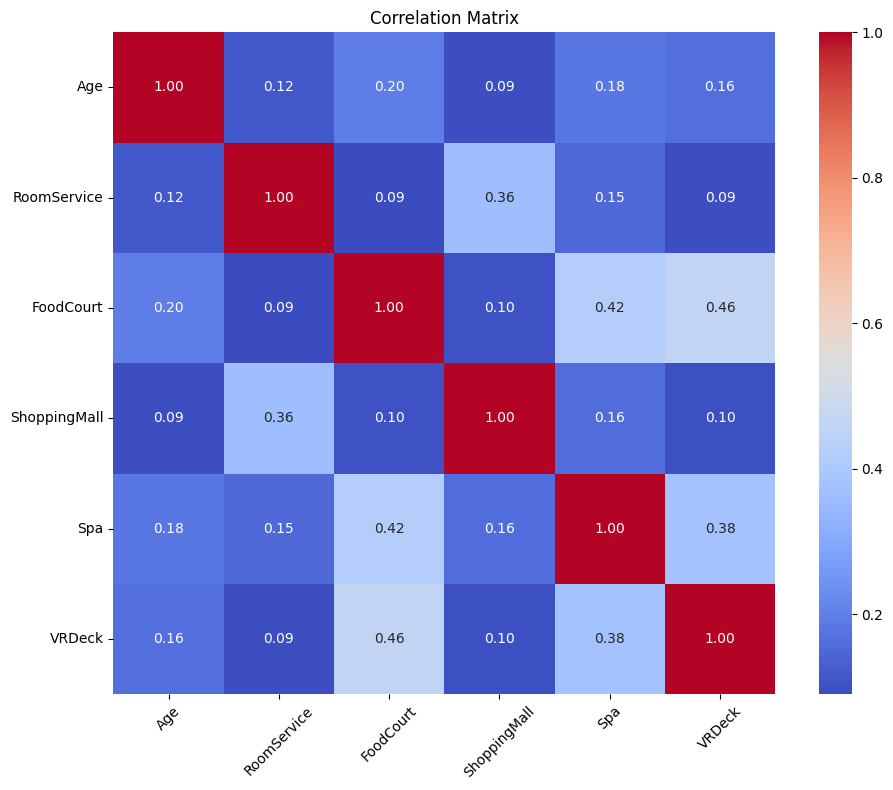

In [11]:
# Correlation matrix
corr_matrix = train.select_dtypes(include=[np.number]).corr()

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

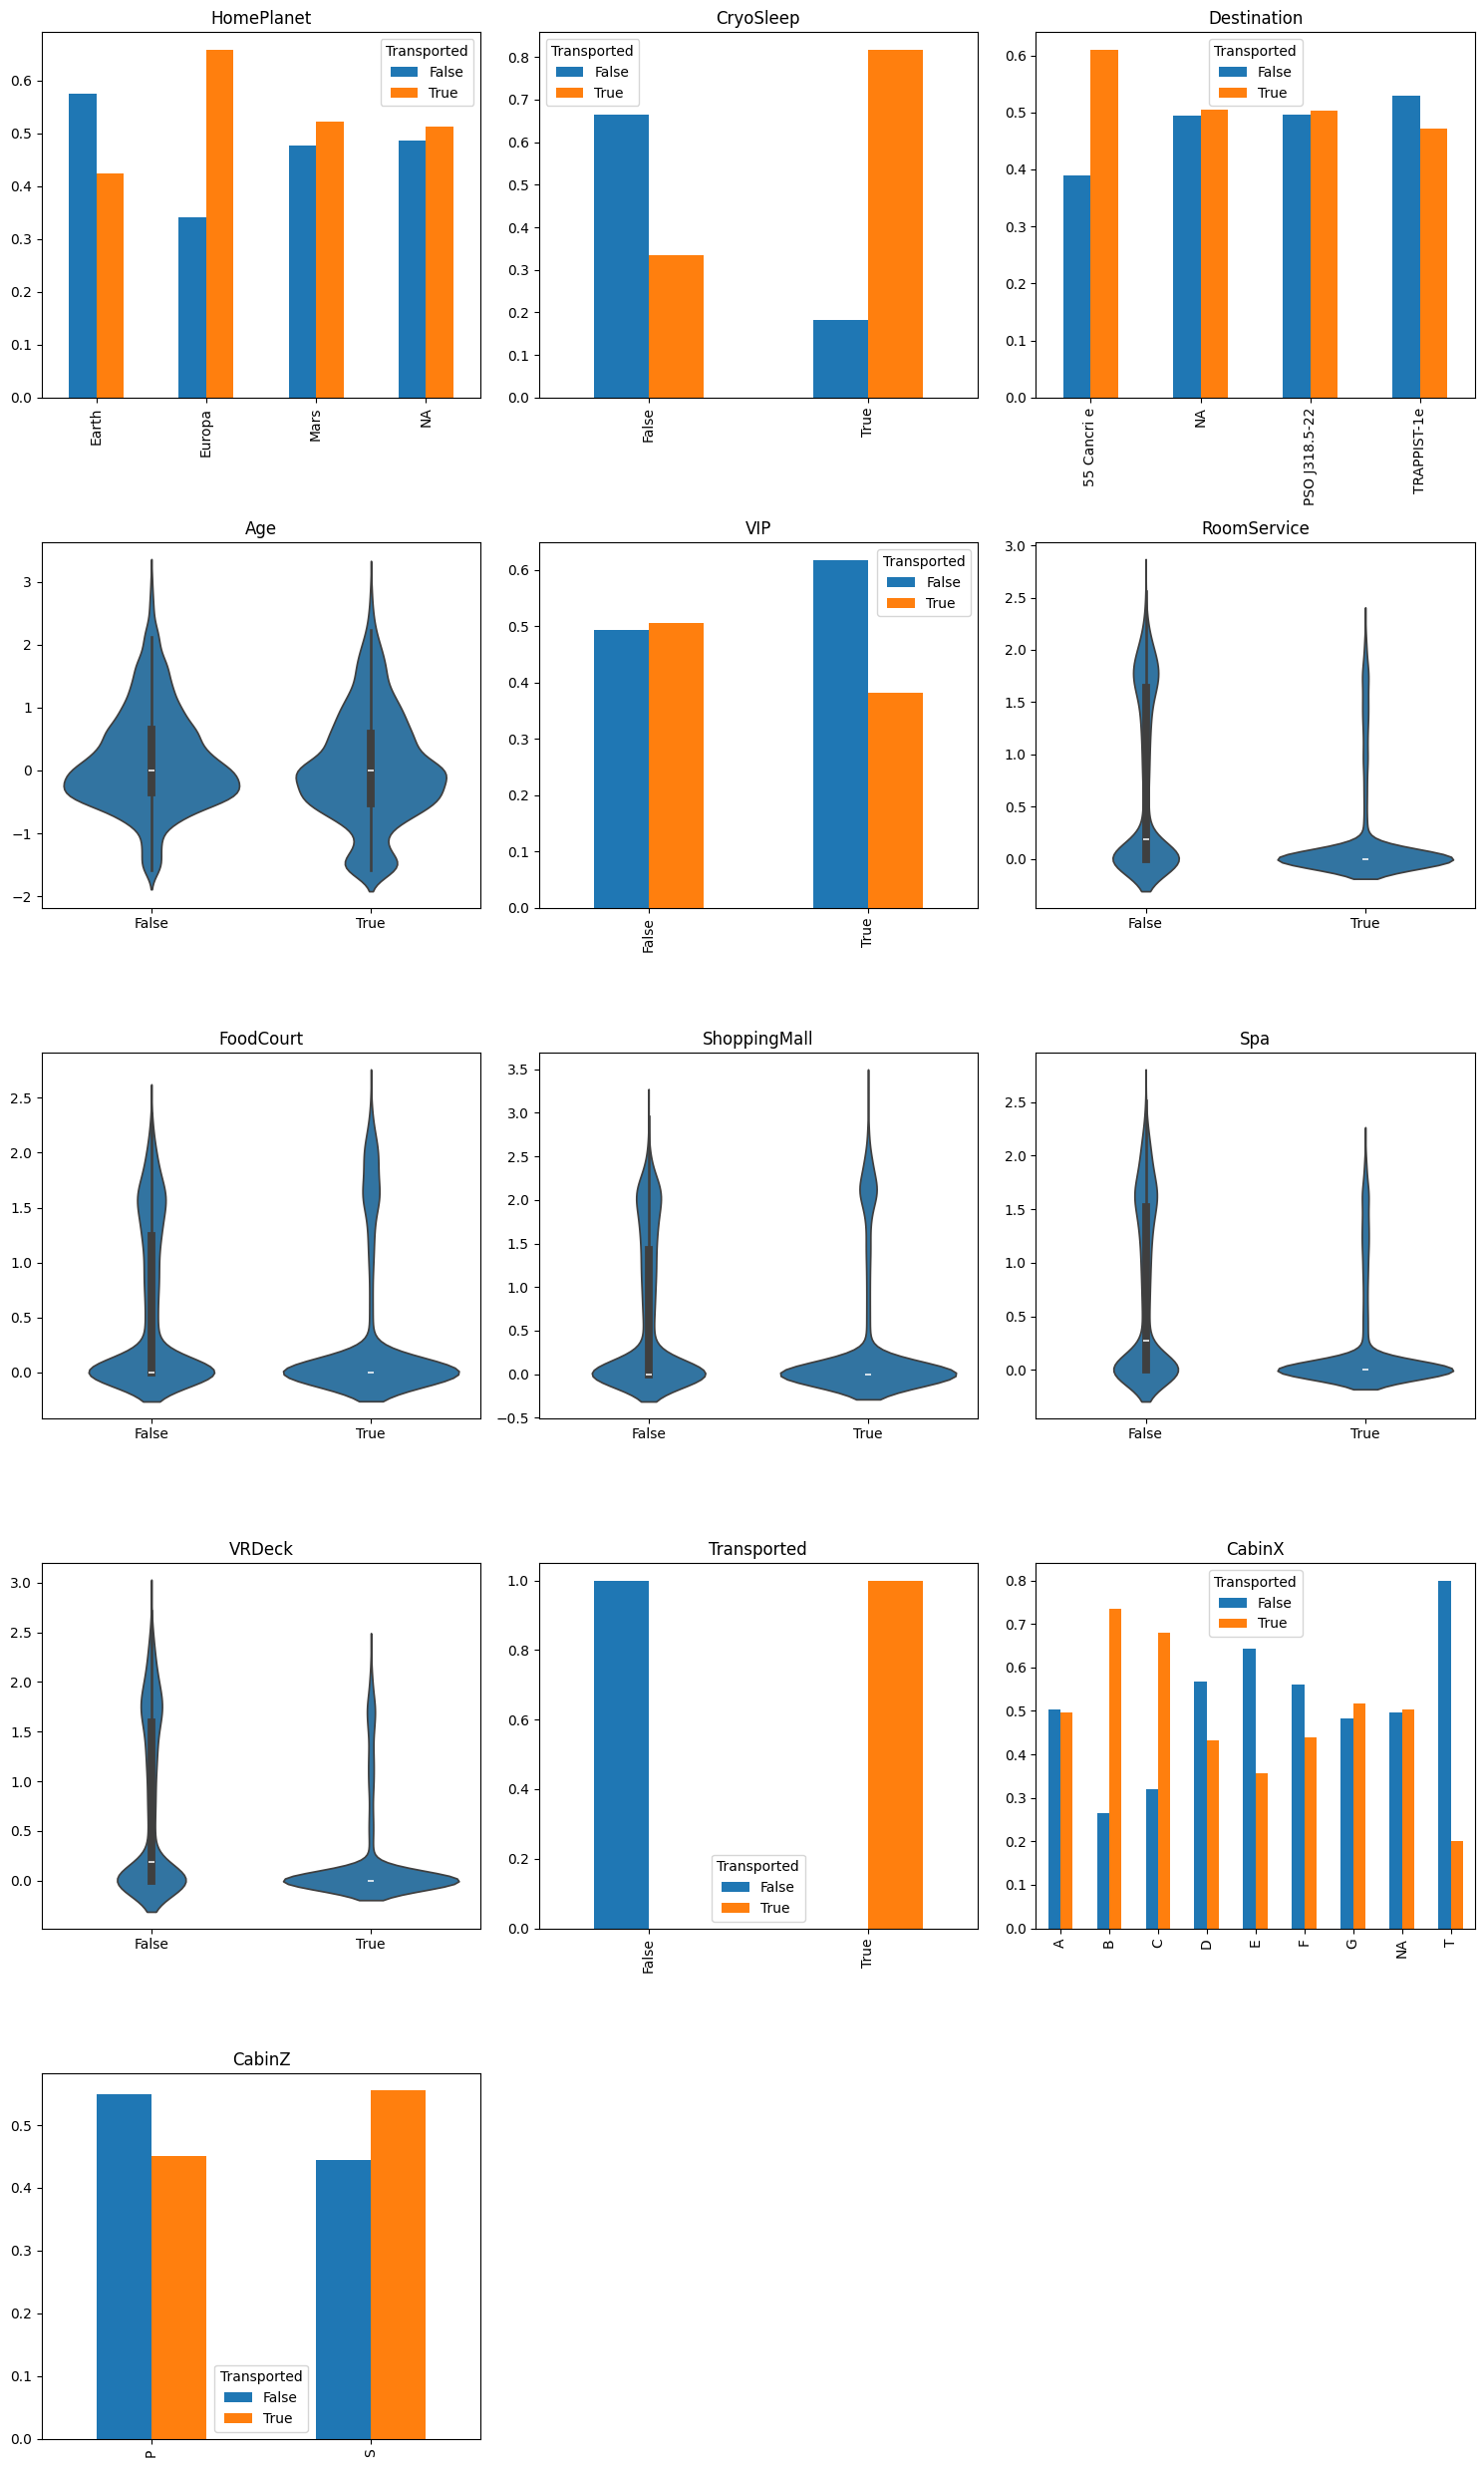

In [12]:
cols = train.columns
n = len(cols)

n_cols = 3  # number of subplot columns
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    
    if np.issubdtype(train[col].dtype, np.float64):
        # train.boxplot(column=col, by="Transported", ax=ax)
        sns.violinplot(
            x="Transported",
            y=col,
            data=train,
            ax=axes[i]
        )
        axes[i].set_title(col)
    else:
        ct = pd.crosstab(train[col], train["Transported"], normalize="index")
        ct.plot(kind="bar", ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("")
plt.tight_layout()
plt.show()

In [13]:
# One Hot Encoding
cat_cols = train.select_dtypes(include=["object"])

Encoder = {}
for col in cat_cols:
    le = sk.preprocessing.OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    
    encoded_train = le.fit_transform(train[[col]])
    encoded_test = le.transform(test[[col]])
    
    new_cols = [f"{col}_{cat}" for cat in le.categories_[0]]
    
    train[new_cols] = encoded_train
    test[new_cols] = encoded_test
    
    train.drop(columns=col, inplace=True)
    test.drop(columns=col, inplace=True)
    
    Encoder[col] = le

Encoder

{'HomePlanet': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
 'CryoSleep': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
 'Destination': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
 'VIP': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
 'CabinX': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
 'CabinZ': OneHotEncoder(handle_unknown='ignore', sparse_output=False)}

In [ ]:
from sklearn.feature_selection import chi2 

X = train.drop(["Transported","Age"], axis=1)
y = train["Transported"].astype(int)

chi_scores, p_values = chi2(X, y)

chi_df = pd.DataFrame({
    "feature": X.columns,
    "chi2_score": chi_scores,
    "p_value": p_values
}).sort_values("chi2_score", ascending=False)

chi_df

,feature,chi2_score,p_value
0,RoomService,1257.449396,1.996104e-275
10,CryoSleep_True,1197.498426,2.132856e-262
3,Spa,1190.297770,7.831980e-261
4,VRDeck,1152.332629,1.396124e-252
9,CryoSleep_False,642.999066,7.441987e-142
2,ShoppingMall,364.171864,3.476858e-81
6,HomePlanet_Europa,205.386948,1.394297e-46
1,FoodCourt,173.255177,1.439600e-39
18,CabinX_B,165.779697,6.180010e-38
5,HomePlanet_Earth,116.869385,3.066094e-27


In [ ]:
from sklearn.feature_selection import f_classif 

X = train.drop(["Transported"], axis=1)
y = train["Transported"].astype(int)

f_scores, p_values = f_classif(X, y)

f_classif_df = pd.DataFrame({
    "feature": X.columns,
    "f_score": f_scores,
    "p_value": p_values
}).sort_values("f_score", ascending=False)

f_classif_df

,feature,f_score,p_value
10,CryoSleep_False,2334.295199,0.000000e+00
11,CryoSleep_True,2334.295199,0.000000e+00
4,Spa,1309.846243,2.762929e-267
1,RoomService,1263.100270,1.950700e-258
5,VRDeck,1126.116258,2.908178e-232
3,ShoppingMall,286.147088,3.500258e-63
7,HomePlanet_Europa,280.812746,4.674960e-62
6,HomePlanet_Earth,255.580886,1.010360e-56
19,CabinX_B,185.951263,6.555742e-42
2,FoodCourt,161.403622,1.181515e-36


In [ ]:
# Drop low value features
# Nah

In [18]:
train_processed = train
test_processed = pd.concat([passengerId,test],axis=1)

train_processed.to_csv('../data/processed/train.csv',index=False)
test_processed.to_csv('../data/processed/test.csv',index=False)